## Preparation

### Libraries import & metadata storage definitions

In [3]:
import os
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
contents_folder = "task_files_3"
checkpoint_dir = os.path.join(contents_folder, "checkpoints")
graph_dir = os.path.join(contents_folder, "graphs")
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Common functions

In [49]:
def bracket_comment(comment: str):
    return "(" + comment + ")" if comment else comment


def rates_histplot_all(rates: pd.DataFrame,
                       with_kde: bool = True,
                       n_bins: int = 10,
                       comment: str = ""):
    fig, ax = plt.subplots(figsize=(5, 3))

    sns.histplot(data=rates.to_numpy().flatten(), kde=with_kde, bins=n_bins)
    ax.set(
        title=f"Rates distribution over all pages {bracket_comment(comment)}",
        xlabel="Rate"
    )

    ax.grid(True, alpha=0.3, zorder=0)
    plt.show()    


def rates_histplot_pages(rates: pd.DataFrame,
                         with_kde: bool = True,
                         n_bins: int = 10,
                         comment: str = ""):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

    for i, column in enumerate(rates.columns):
        sns.histplot(
            data=rates, 
            x=column, 
            kde=with_kde, 
            ax=axes[i], 
            color=f'C{i}', 
            element="step", 
            bins=n_bins
        )
        axes[i].set(
            title=f"{column}",
            xlabel="Rate",
            xlim=(0,1)
        )
        if i:
            axes[i].set_ylabel("")
        axes[i].grid(True, alpha=0.3, zorder=0)

    plt.suptitle(f"Rates distribution over pages {bracket_comment(comment)}", fontsize=16)
    plt.tight_layout()
    plt.show()


def rates_histplot_all_compare(rates_list: list[pd.DataFrame],
                               rates_names: list[str],
                               with_kde: bool = True,
                               n_bins: int = 10,
                               multiple_option: str = "layer",
                               comment: str = ""):
    fig, ax = plt.subplots(figsize=(6, 3))
    
    rates_long_list = []
    for i, (rates_df, name) in enumerate(zip(rates_list, rates_names)):
        rates_melted = rates_df.melt(var_name="column", value_name="rate")
        rates_melted["rates_group"] = name
        rates_long_list.append(rates_melted)
    rates_all = pd.concat(rates_long_list, ignore_index=True)
    
    sns.histplot(
        data=rates_all,
        x="rate", 
        hue="rates_group",
        kde=with_kde, 
        bins=n_bins,
        alpha=0.6,
        multiple=multiple_option,
        element="step"
    )
    ax.set(
        title=f"Rates distribution comparison over groups: {comment}",
        xlabel="Rate"
    )

    ax.grid(True, alpha=0.3, zorder=0)
    plt.show() 


def rates_histplot_pages_compare(rates_list: list[pd.DataFrame],
                                 rates_names: list[str],
                                 with_kde: bool = True,
                                 n_bins: int = 10,
                                 multiple_option: str = "layer",
                                 comment: str = ""):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

    rates_long_list = []
    for i, (rates_df, name) in enumerate(zip(rates_list, rates_names)):
        rates_melted = rates_df.melt(var_name="page", value_name="rate")
        rates_melted["rates_group"] = name
        rates_long_list.append(rates_melted)
    rates_all = pd.concat(rates_long_list, ignore_index=True)
    for i, page in enumerate(rates_all.drop(columns="rates_group")["page"].unique()):
        page_data = rates_all[rates_all["page"] == page]
        
        sns.histplot(
            data=page_data, 
            x="rate",
            hue="rates_group",
            kde=with_kde, 
            ax=axes[i], 
            multiple=multiple_option,
            element="step", 
            bins=n_bins
        )
        axes[i].set(
            title=f"{page}",
            xlabel="Rate",
            xlim=(0, 1)
        )
        ylabel = "" if i else "Frequency"
        axes[i].set_ylabel(ylabel)
        
        if i != 4:
            axes[i].get_legend().remove()
        if i:
            axes[i].set_ylabel("")
        axes[i].grid(True, alpha=0.3, zorder=0)

    plt.suptitle(f"Rates distribution over pages {bracket_comment(comment)}", fontsize=16)
    plt.tight_layout()
    plt.show()


def print_distr_conclusion(pvalues: list,
                           distr_name: str,
                           sign_level: float = 0.05,
                           is_by_pages: bool = True):
    print(f"Checking hypothesis with significance level {sign_level}:")
    if is_by_pages or hasattr(pvalues, '__iter__'):
        pages_or_rates = "page" if is_by_pages else "rates"
        for i in range(len(pvalues)):
            conclusion = "" if pvalues[i] >= sign_level else "non-"
            print(f"   {pages_or_rates} {i+1} p-value = {pvalues[i]:.6f}  =>  "
                f"rates are {conclusion}{distr_name} distributed")
    else:
        conclusion = "" if pvalues >= sign_level else "non-"
        print(f"   rates p-value = {pvalues:.6f}  =>  "
              f"rates are {conclusion}{distr_name} distributed")

## Assessors rating modelling

### Main constants & functions

In [6]:
n_pages = 5
n_good_assessors = 8500
n_weak_assessors = 1000
n_frauders = 500

In [7]:
def generate_good_rates(n_pages: int,
                        n_assessors: int):
    rates_dict = {}

    rates_dict["Page_1"] = np.random.beta(1, 0.2, size=n_assessors)

    for i in range(1, n_pages):
        column_name = f"Page_{i+1}"
        rates_dict[column_name] = np.random.uniform(
            low=1-(i-1)/n_pages if i else 1-i/n_pages, 
            high=1-(i+1)/n_pages, 
            size=n_assessors // 5
        )
        rates_dict[column_name] = np.concat((
            rates_dict[column_name], 
            np.random.uniform(0, 1, size=(n_assessors // 5 * 4))
        ))

    return np.clip(pd.DataFrame(rates_dict).astype(float), 0, 1)


def generate_rates(n_pages: int,
                   n_assessors: int,
                   distribution,
                   *args):
    rates_dict = {}
    for i in range(n_pages):
        column_name = f"Page_{i+1}"
        rates_dict[column_name] = distribution(size=n_assessors, *args)

    return np.clip(pd.DataFrame(rates_dict).astype(float), 0, 1)

### Rates dataset creation

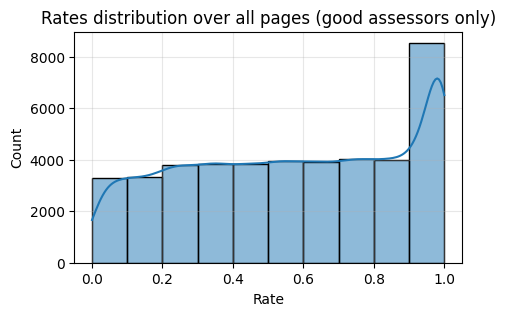

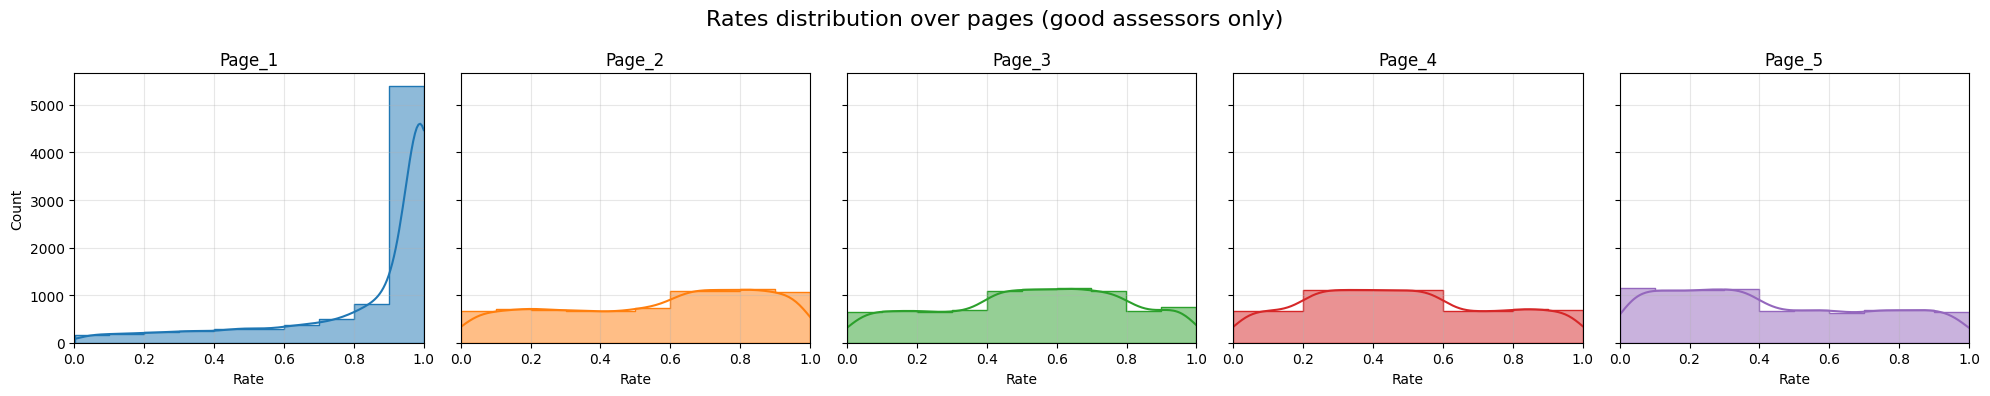

In [8]:
np.random.seed(40)

rates = generate_good_rates(n_pages, n_good_assessors)

comment_good = "good assessors only"
rates_histplot_all(rates, comment=comment_good)
rates_histplot_pages(rates, comment=comment_good)

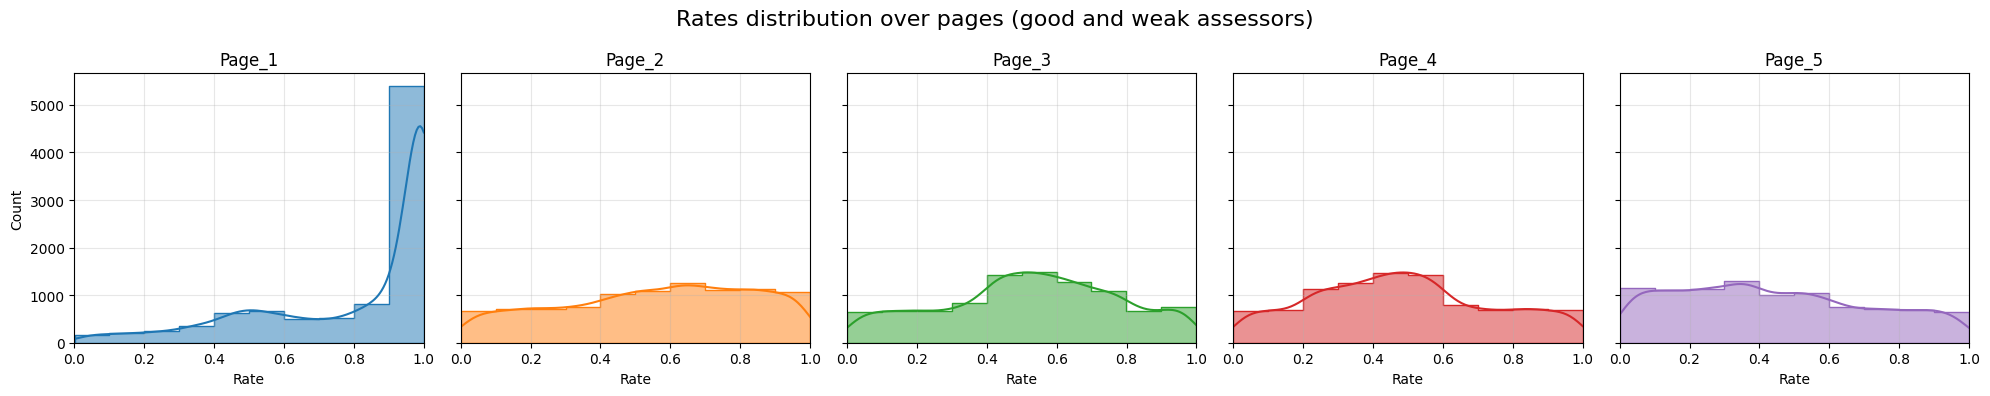

In [9]:
np.random.seed(40)

rates = pd.concat((rates, 
                   generate_rates(n_pages, n_weak_assessors, np.random.normal, 0.5, 0.1)))
comment_weak = "good and weak assessors"
rates_histplot_pages(rates, comment=comment_weak)

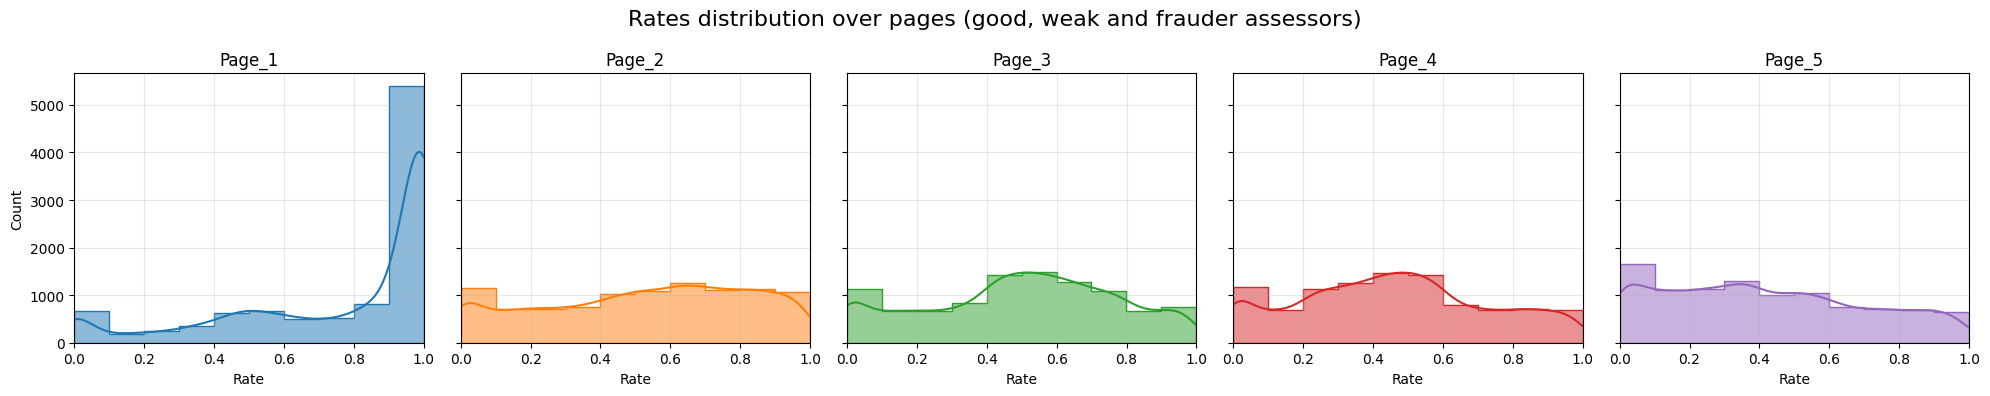

In [10]:
np.random.seed(40)

rates = pd.concat((rates, 
                   generate_rates(n_pages, n_frauders, np.random.randint, 0, 1)))
comment_all = "good, weak and frauder assessors"
rates_histplot_pages(rates, comment=comment_all)

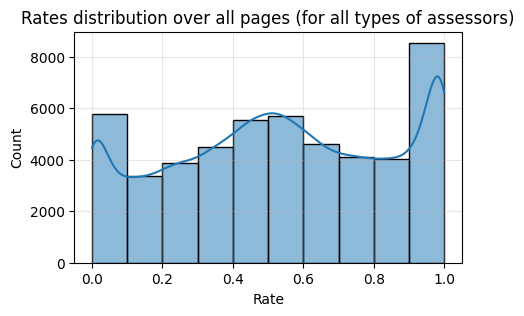

In [19]:
np.random.seed(42)

rates = rates.sample(frac=1).reset_index(drop=True)
rates_histplot_all(rates, comment="for all types of assessors")

In [12]:
rates.describe()

,Page_1,Page_2,Page_3,Page_4,Page_5
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.760159,0.525592,0.497018,0.458713,0.419735
std,0.307502,0.293660,0.271709,0.269408,0.285552
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.557954,0.289861,0.303278,0.257507,0.177170
50%,0.931162,0.557500,0.516850,0.453931,0.386750
75%,0.997791,0.771052,0.700156,0.643552,0.636526
max,1.000000,0.999962,0.999496,0.999799,0.999877


## A/B testing

### 2 groups split

In [20]:
rates_A = rates.head(rates.shape[0] // 2)
comment_A = "group A, control"
rates_B = rates.tail(rates.shape[0] // 2)
comment_B = "group B, test"

In [14]:
rates_A.index, rates_B.index

(RangeIndex(start=0, stop=5000, step=1),
 RangeIndex(start=5000, stop=10000, step=1))

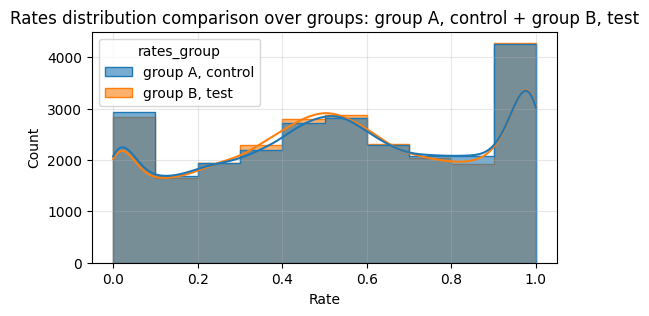

In [24]:
rates_histplot_all_compare(
    [rates_A, rates_B], 
    [comment_A, comment_B], 
    comment=comment_A+" + "+comment_B,
    multiple_option="layer"
)

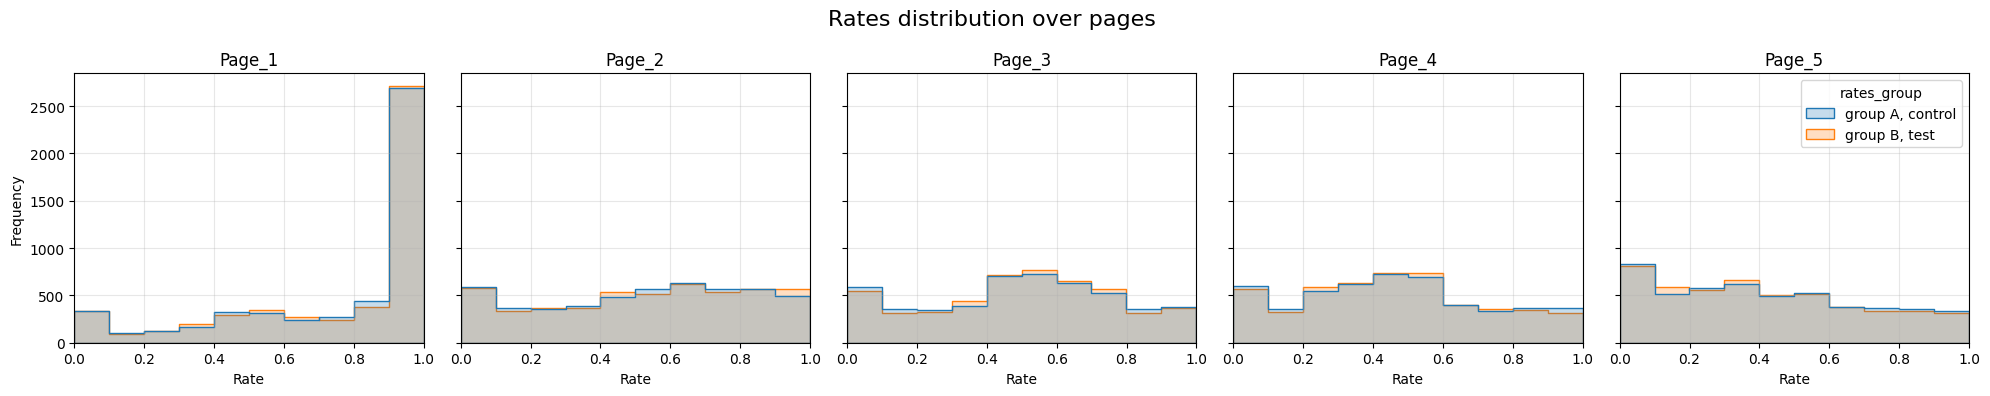

In [28]:
rates_histplot_pages_compare(
    [rates_A, rates_B],
    [comment_A, comment_B],
    with_kde=False
)

По построению (перемешиванию случайных метрик + 5000 элементам в каждой выборке) между выборками не должно быть статистически значимого различия. Проверим это. Т.к. распределения оценок по каждой странице визуально не нормальны, используем критерий Манна-Уитни.

In [22]:
stats_u_pages, pvalues_u_pages = stats.mannwhitneyu(rates_A, rates_B)
stats_u_pages, pvalues_u_pages

(array([12523577., 12333342., 12354426., 12576752., 12702944.]),
 array([0.87024694, 0.24823318, 0.31317831, 0.59489456, 0.15970886]))

In [35]:
print_distr_conclusion(pvalues_u_pages, "identically")

Checking hypothesis with significance level 0.05:
   page 1 p-value = 0.870247  =>  rates are identically distributed
   page 2 p-value = 0.248233  =>  rates are identically distributed
   page 3 p-value = 0.313178  =>  rates are identically distributed
   page 4 p-value = 0.594895  =>  rates are identically distributed
   page 5 p-value = 0.159709  =>  rates are identically distributed


### Changing the test group distribution

Изменим распределение тестовой подвыборки: пусть оцениваемые этой выборкой страницы поисковой выдачи были так хороши, что оценка их релевантности асессорами не опускалась ниже 0.2. Проверим статистическую значимость изменений.

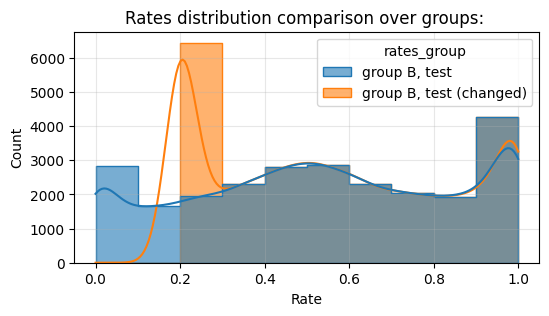

In [53]:
rates_B_new = rates_B.clip(lower=0.2)
rates_histplot_all_compare(
    [rates_B, rates_B_new],
    [comment_B, comment_B+" (changed)"],
    with_kde=True
)

In [72]:
print("The value clipping change affected:")
for page in rates_B.columns:
    print(f"    {page}: {rates_B[rates_B[page] < 0.2][page].size} sample rates which is "
          f"{rates_B[rates_B[page] < 0.2][page].size / rates_B.size:.4%} of all samples")

The value clipping change affected:
    Page_1: 434 sample rates which is 1.7360% of all samples
    Page_2: 914 sample rates which is 3.6560% of all samples
    Page_3: 860 sample rates which is 3.4400% of all samples
    Page_4: 892 sample rates which is 3.5680% of all samples
    Page_5: 1399 sample rates which is 5.5960% of all samples


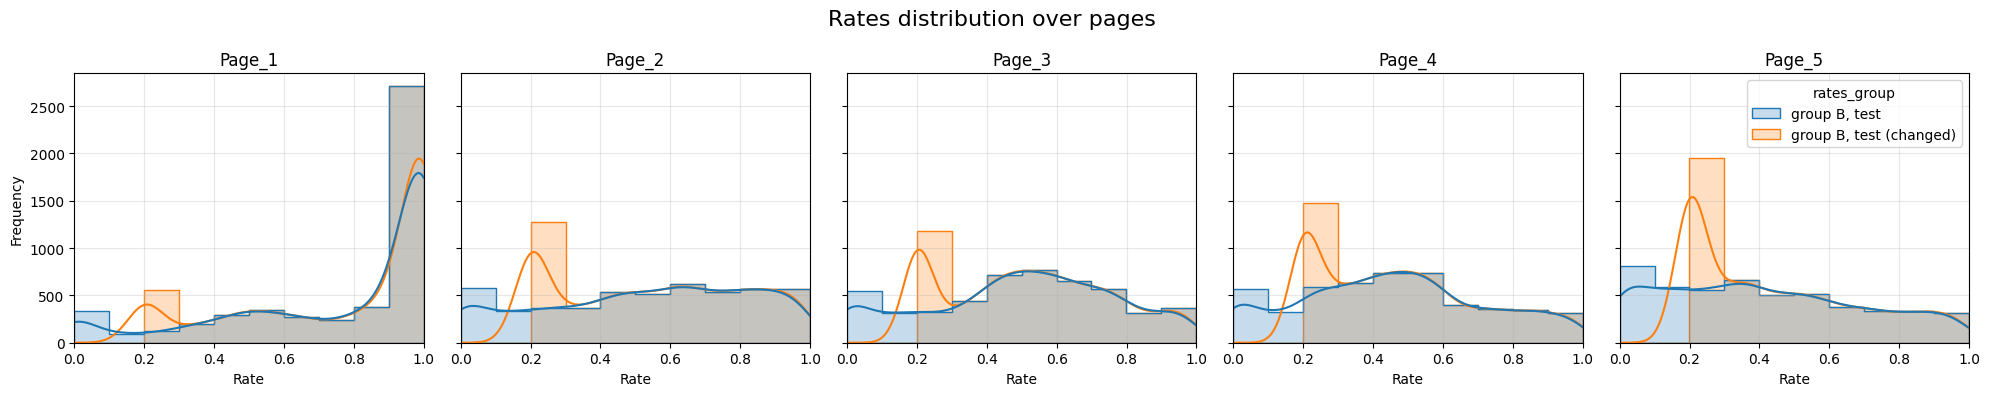

In [74]:
rates_histplot_pages_compare(
    [rates_B, rates_B_new],
    [comment_B, comment_B+" (changed)"],
    with_kde=True
)

In [73]:
stats_u_pages_new, pvalues_u_pages_new = stats.mannwhitneyu(rates_A, rates_B_new)
print_distr_conclusion(pvalues_u_pages_new, "identically")

Checking hypothesis with significance level 0.05:
   page 1 p-value = 0.633049  =>  rates are identically distributed
   page 2 p-value = 0.000021  =>  rates are non-identically distributed
   page 3 p-value = 0.000091  =>  rates are non-identically distributed
   page 4 p-value = 0.015496  =>  rates are non-identically distributed
   page 5 p-value = 0.000001  =>  rates are non-identically distributed


In [52]:
stats_u_all_new, pvalues_u_all_new = stats.mannwhitneyu(
    rates_A.values.flatten(), 
    rates_B_new.values.flatten()
)
print_distr_conclusion(pvalues_u_all_new, "identically", is_by_pages = False)

Checking hypothesis with significance level 0.05:
   rates p-value = 0.000000  =>  rates are non-identically distributed


**Вывод:** изменения оказали статистически значимое влияние на общую подвыборку, но не на все ее части: статистика оценок страницы 1 изменилась несущественно. Это показывает ориентацию теста Манна-Уитни на оценку изменения формы распределения, а не количество затронутых изменением данных.